# **Bahria University**
# **Department of Computer Science**  
---
---
## **Natural Language Peocessing**  
### **Movie Review Sentiment Analysis With Streamlit GUI**  
### **Assignment #3**
### ***(Model Implementaation and Evaluation)***
### **Date:**  Monday, 27 April 2026

---
---
###**Submitted by:**  MUHAMMAD HAROON (01-134231-052)
###**Submitted by:** Muhammad Sammi (01-134231-063)
---
---
**Submitted to:**  Ma'am Saira Hameed
---
---

In [1]:
import pandas as pd
import string
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment Analysis/lldata.txt",
                  sep='|', header=None, names=['label', 'x','message'])

df.head()


,label,x,message
0,5,23191,WHAT AN AWESOME MOVIE!! The best i've seen in ...
1,5,6776,best movie ever funnyest thing in the world wh...
2,1,21271,It's Elvis for gods sake. Nothing but a vehicl...
3,5,13052,Probably one of the best ten pictures of all t...
4,5,7468,"A very funny, super-likable movie that capital..."


In [3]:
df.drop(['x'], axis=1, inplace=True)
df.head(10)

,label,message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...
1,5,best movie ever funnyest thing in the world wh...
2,1,It's Elvis for gods sake. Nothing but a vehicl...
3,5,Probably one of the best ten pictures of all t...
4,5,"A very funny, super-likable movie that capital..."
5,5,I JUST SAW THIS LAST NIGHT! I THINK THAT SEAN ...
6,5,Awesome - the book is incredible and although ...
7,5,F#####G awesome best remake ever of a hooror s...
8,5,This was my first movie that I saw as a three ...
9,5,Excellent movie in many ways. Acting was terri...


In [4]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 13864
Number of columns: 2


In [5]:
df['label'].value_counts()

,count
label,
5,11129
1,2735


In [6]:
print("Difference ::",df['label'].value_counts()[5]-df['label'].value_counts()[1])

Difference :: 8394



# Severe Class Imbalance

Naive Bayes learns mostly from the positive class, because it has thousands of examples.
The negative class is extremely small, so the model:


1.   cannot learn negative patterns

2.   starts predicting positive for almost everything


3. resulting in many FP

resulting in many FP.

This is the primary reason.
# Solution
Use another dataset then add negative reviews to balance dataset

In [7]:
df1=pd.read_csv('/content/drive/MyDrive/Sentiment Analysis/IMDB Dataset.csv')

In [8]:
df1 = df1.rename(columns={'review': 'message'})
df1 = df1.rename(columns={'sentiment': 'label'})

df1['label']=df1['label'].map({'positive':5,'negative':1})
df1.head()

,message,label
0,One of the other reviewers has mentioned that ...,5
1,A wonderful little production. <br /><br />The...,5
2,I thought this was a wonderful way to spend ti...,5
3,Basically there's a family where a little boy ...,1
4,"Petter Mattei's ""Love in the Time of Money"" is...",5


In [9]:
filtered_df = df1[df1['label'] == 1]
filtered_df.shape


(25000, 2)

In [10]:
df_final=filtered_df.head(6000)
df_final.shape


(6000, 2)

In [11]:
correct_order = df.columns
df_final = df_final[correct_order]


In [12]:
df.columns == df_final.columns

array([ True,  True])

In [13]:
df = pd.concat([df, df_final], ignore_index=True)
df['label'].value_counts()

,count
label,
5,11129
1,8735


df1=pd.read_csv('/content/drive/MyDrive/Sentiment Analysis/IMDB Dataset.csv')
df1 = df1.rename(columns={'review': 'message'})
df1 = df1.rename(columns={'sentiment': 'label'})

df1['label']=df1['label'].map({'positive':5,'negative':1})
df1.head()
df=df1

#1. Lowercasing

In [14]:
df['clean_message']=df['message'].str.lower()
df.head()

,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,what an awesome movie!! the best i've seen in ...
1,5,best movie ever funnyest thing in the world wh...,best movie ever funnyest thing in the world wh...
2,1,It's Elvis for gods sake. Nothing but a vehicl...,it's elvis for gods sake. nothing but a vehicl...
3,5,Probably one of the best ten pictures of all t...,probably one of the best ten pictures of all t...
4,5,"A very funny, super-likable movie that capital...","a very funny, super-likable movie that capital..."


In [15]:
df.drop_duplicates(inplace=True)
df.shape

(19762, 3)

#2.	Handling numerals, punctuation

In [16]:
def remove_html_tags(text):
    clean_text = re.sub(r'<.*?>', '', text)
    return clean_text
df['clean_message']=df['clean_message'].apply(lambda x : remove_html_tags(x))
df.head()

,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,what an awesome movie!! the best i've seen in ...
1,5,best movie ever funnyest thing in the world wh...,best movie ever funnyest thing in the world wh...
2,1,It's Elvis for gods sake. Nothing but a vehicl...,it's elvis for gods sake. nothing but a vehicl...
3,5,Probably one of the best ten pictures of all t...,probably one of the best ten pictures of all t...
4,5,"A very funny, super-likable movie that capital...","a very funny, super-likable movie that capital..."


In [17]:
def remove_punctuations(text):
  punc=string.punctuation
  text=text.translate(str.maketrans('','',punc))
  return text
df['clean_message']=df['clean_message'].apply(lambda x : remove_punctuations(x))
df.head()

,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,what an awesome movie the best ive seen in a w...
1,5,best movie ever funnyest thing in the world wh...,best movie ever funnyest thing in the world wh...
2,1,It's Elvis for gods sake. Nothing but a vehicl...,its elvis for gods sake nothing but a vehicle ...
3,5,Probably one of the best ten pictures of all t...,probably one of the best ten pictures of all t...
4,5,"A very funny, super-likable movie that capital...",a very funny superlikable movie that capitaliz...


In [18]:
def remove_numerals(text):
  return re.sub(r'\d+', '', text)
df['clean_message']=df['clean_message'].apply(lambda x : remove_numerals(x))
df.head()

,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,what an awesome movie the best ive seen in a w...
1,5,best movie ever funnyest thing in the world wh...,best movie ever funnyest thing in the world wh...
2,1,It's Elvis for gods sake. Nothing but a vehicl...,its elvis for gods sake nothing but a vehicle ...
3,5,Probably one of the best ten pictures of all t...,probably one of the best ten pictures of all t...
4,5,"A very funny, super-likable movie that capital...",a very funny superlikable movie that capitaliz...


#3. Tokenization

In [19]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
def tokenization(text):
  tokens=word_tokenize(text)
  return tokens
df['clean_message']=df['clean_message'].apply(lambda x : tokenization(x))
df.head()

,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,"[what, an, awesome, movie, the, best, ive, see..."
1,5,best movie ever funnyest thing in the world wh...,"[best, movie, ever, funnyest, thing, in, the, ..."
2,1,It's Elvis for gods sake. Nothing but a vehicl...,"[its, elvis, for, gods, sake, nothing, but, a,..."
3,5,Probably one of the best ten pictures of all t...,"[probably, one, of, the, best, ten, pictures, ..."
4,5,"A very funny, super-likable movie that capital...","[a, very, funny, superlikable, movie, that, ca..."


#4. Step Words Removal

In [21]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:

from nltk.corpus import stopwords

# 1. Prepare the custom stopword set
stop_words = set(stopwords.words('english'))
negations = {"no", "not", "nor", "never"}
custom_stop_words = stop_words - negations

# 2. Define optimized removal function
def remove_StepWordss(token_list):
    """
    Filters out stopwords from a tokenized list while preserving negations.
    """
    return [word for word in token_list if word.lower() not in custom_stop_words]

# 3. Apply to the tokenized column
df['clean_message'] = df['clean_message'].apply(remove_StepWordss)

# 4. Preview the change
print("Original Tokens (Sample):", df['clean_message'].iloc[0][:5])
df.head()

Original Tokens (Sample): ['awesome', 'movie', 'best', 'ive', 'seen']


,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,"[awesome, movie, best, ive, seen, dennis, quai..."
1,5,best movie ever funnyest thing in the world wh...,"[best, movie, ever, funnyest, thing, world, wh..."
2,1,It's Elvis for gods sake. Nothing but a vehicl...,"[elvis, gods, sake, nothing, vehicle, others, ..."
3,5,Probably one of the best ten pictures of all t...,"[probably, one, best, ten, pictures, time, inc..."
4,5,"A very funny, super-likable movie that capital...","[funny, superlikable, movie, capitalizes, anxi..."


#5. Lemmatization

In [23]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [24]:

Lemmatizer=WordNetLemmatizer()
def lemmatization(text):
  lemmatized_text=[Lemmatizer.lemmatize(token) for token in text]
  return lemmatized_text
df['clean_message']=df['clean_message'].apply(lambda x : lemmatization(x))
df.head(10)


,label,message,clean_message
0,5,WHAT AN AWESOME MOVIE!! The best i've seen in ...,"[awesome, movie, best, ive, seen, dennis, quai..."
1,5,best movie ever funnyest thing in the world wh...,"[best, movie, ever, funnyest, thing, world, wh..."
2,1,It's Elvis for gods sake. Nothing but a vehicl...,"[elvis, god, sake, nothing, vehicle, others, m..."
3,5,Probably one of the best ten pictures of all t...,"[probably, one, best, ten, picture, time, incr..."
4,5,"A very funny, super-likable movie that capital...","[funny, superlikable, movie, capitalizes, anxi..."
5,5,I JUST SAW THIS LAST NIGHT! I THINK THAT SEAN ...,"[saw, last, night, think, sean, julia, great, ..."
6,5,Awesome - the book is incredible and although ...,"[awesome, book, incredible, although, movie, s..."
7,5,F#####G awesome best remake ever of a hooror s...,"[fg, awesome, best, remake, ever, hooror, far]"
8,5,This was my first movie that I saw as a three ...,"[first, movie, saw, three, year, old, get, see..."
9,5,Excellent movie in many ways. Acting was terri...,"[excellent, movie, many, way, acting, terrific..."


#6. Stemming

#7. Mapping labels and Joining tokens

In [25]:
df['label']=df['label'].map({1:0,5:1})
df['clean_message']=df['clean_message'].apply(lambda x : " ".join(x))
df.head(10)


,label,message,clean_message
0,1,WHAT AN AWESOME MOVIE!! The best i've seen in ...,awesome movie best ive seen dennis quaid show ...
1,1,best movie ever funnyest thing in the world wh...,best movie ever funnyest thing world whoever d...
2,0,It's Elvis for gods sake. Nothing but a vehicl...,elvis god sake nothing vehicle others make mon...
3,1,Probably one of the best ten pictures of all t...,probably one best ten picture time incredible ...
4,1,"A very funny, super-likable movie that capital...",funny superlikable movie capitalizes anxiety f...
5,1,I JUST SAW THIS LAST NIGHT! I THINK THAT SEAN ...,saw last night think sean julia great actor sa...
6,1,Awesome - the book is incredible and although ...,awesome book incredible although movie somewha...
7,1,F#####G awesome best remake ever of a hooror s...,fg awesome best remake ever hooror far
8,1,This was my first movie that I saw as a three ...,first movie saw three year old get see dvd awe...
9,1,Excellent movie in many ways. Acting was terri...,excellent movie many way acting terrific kostn...


#8. Vectrization using TF-IDF

In [26]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['clean_message'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary (sample):\n", vectorizer.get_feature_names_out()[:20])
print("TF-IDF Matrix :\n", tfidf_matrix.toarray()[:20])


TF-IDF matrix shape: (19762, 64713)
Vocabulary (sample):
 ['aaa' 'aaaa' 'aaaaaaaa' 'aaaaaahahahahahaha' 'aaaaaahhhhh' 'aaaaaahhhhhh'
 'aaaaaarrrrrrggggghhhhh' 'aaaaahhhhh' 'aaaaahhhhhh'
 'aaaaarrrrrggggghhhhh' 'aaaahahah' 'aaaahahahahaha' 'aaaahahahahahahaha'
 'aaaahhhhh' 'aaaahhhhhhh' 'aaaand' 'aaaarghhhh' 'aaaarrgh' 'aaahhh'
 'aaall']
TF-IDF Matrix :
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


#8. Vectrization using Bag OF Words(BoW) representation

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize the CountVectorizer (Bag of Words)
# You can add parameters like stop_words='english' or ngram_range=(1,2)
bow_vectorizer = CountVectorizer()

# 2. Fit and transform the processed text
bow_matrix = bow_vectorizer.fit_transform(df['clean_message'])

# 3. View the results
print("BoW matrix shape:", bow_matrix.shape)
print("Vocabulary (sample):\n", bow_vectorizer.get_feature_names_out()[:20])
print("\nBoW Matrix (First 20 rows/samples):\n", bow_matrix.toarray()[:20])

BoW matrix shape: (19762, 64713)
Vocabulary (sample):
 ['aaa' 'aaaa' 'aaaaaaaa' 'aaaaaahahahahahaha' 'aaaaaahhhhh' 'aaaaaahhhhhh'
 'aaaaaarrrrrrggggghhhhh' 'aaaaahhhhh' 'aaaaahhhhhh'
 'aaaaarrrrrggggghhhhh' 'aaaahahah' 'aaaahahahahaha' 'aaaahahahahahahaha'
 'aaaahhhhh' 'aaaahhhhhhh' 'aaaand' 'aaaarghhhh' 'aaaarrgh' 'aaahhh'
 'aaall']

BoW Matrix (First 20 rows/samples):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


# **Comparison: Which Technique is Better?**
There is no universally “perfect” representation method; however, **TF-IDF is generally more effective than Bag of Words (BoW)** for most real-world text processing tasks, especially in classification and information retrieval.

## **Comparison Overview**

| Feature                       | Bag of Words (BoW)                                      | TF-IDF                                                        |
| :---------------------------- | :------------------------------------------------------ | :------------------------------------------------------------ |
| **Core Idea**                 | Represents text using raw word counts.                  | Assigns weights based on word importance across documents.    |
| **Treatment of Common Words** | Frequently occurring words dominate the representation. | Common words are down-weighted using inverse frequency.       |
| **Discriminative Power**      | Limited=> treats all words equally.                       | High=>emphasizes words that distinguish documents.             |
| **Semantic Relevance**        | Ignores importance; purely frequency-based.             | Captures relative importance of terms.                        |
| **Typical Use Cases**         | Basic tasks, small datasets, quick prototypes.          | Search engines, document ranking, classification, clustering. |

---
---

## **Why TF-IDF Typically Outperforms BoW**

TF-IDF improves upon BoW by combining **local importance** (within a document) and **global rarity** (across all documents). This helps the model focus on informative features instead of noise.


* **Term Frequency (TF):** Measures how often a term appears in a specific document.
* **Inverse Document Frequency (IDF):** Reduces the weight of terms that appear frequently across many documents.

## **Intuition**

* Words like *“the”*, *“is”*, or *“message”* appear in almost every document → **low IDF → low importance**
* Words that are rare but meaningful → **high IDF → strong distinguishing power**

As a result, TF-IDF filters out noise and highlights keywords that better represent the document’s content.

---
---

## **Practical Verdict**

* **Use Bag of Words (BoW)** when:

  * Simplicity and speed are priorities
  * Dataset is small or highly domain-specific
  * Word frequency alone is a strong signal

* **Use TF-IDF** when:

  * You need better feature quality for ML models
  * Documents vary in length and vocabulary
  * Distinguishing between documents is important (e.g., classification, search ranking)

---
---




# **Naïve Bayes Implementation**

#Step_1 Setting Lebels

In [28]:
x_label = tfidf_matrix
y_label = df['label']

#Step_2 splitting the data

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x_label,y_label,test_size=0.2,random_state=42)

#Step_3 Training the algo



In [30]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)


MultinomialNB()

In [31]:
y_pred = nb_model.predict(x_test)

#Step_4 Model Evaluation

In [32]:
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Confusion Matrix:
 [[1618  124]
 [ 222 1989]]
Accuracy: 0.9125
Precision: 0.9413
Recall: 0.8996
F1 Score: 0.9200


**Confussion Matrix**

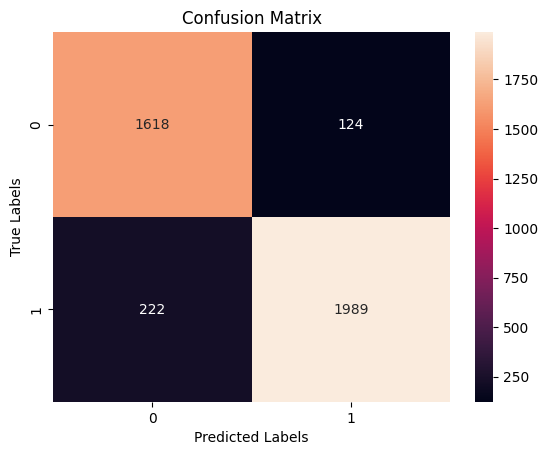

In [33]:

sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# **Model Evaluation: Sentiment Analysis Results**

After training the model using **TF-IDF** features and **Custom Stopword Removal** (preserving negations), we evaluated the performance. Below is the breakdown of the model's ability to classify movie reviews.

---

## **1. Confusion Matrix Breakdown**

The confusion matrix shows exactly where the model is making correct predictions and where it is getting "confused."

| | **Predicted Negative** | **Predicted Positive** |
| :--- | :--- | :--- |
| **Actual Negative** | **1,618 (True Negatives)** | 124 (False Positives) |
| **Actual Positive** | 222 (False Negatives) | **1,989 (True Positives)** |



* **True Negatives (1,618):** Reviews correctly identified as **Negative**.
* **True Positives (1,989):** Reviews correctly identified as **Positive**.
* **False Positives (124):** "False Alarms"—The model predicted positive, but the user actually hated the movie.
* **False Negatives (222):** "Misses"—The model predicted negative, but the review was actually positive.

---

## **2. Key Performance Metrics**

| Metric | Score | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | **91.25%** | Overall, the model is correct in 9 out of 10 cases. |
| **Precision** | **94.13%** | High trust: When the model says a review is "Positive," it is correct 94% of the time. |
| **Recall** | **89.96%** | The model successfully captured 90% of all positive reviews in the dataset. |
| **F1-Score** | **92.00%** | A balanced score showing high stability between Precision and Recall. |

---

## **3. Final Interpretation**

### **Why are these results strong?**
1.  **Negation Handling:** By preserving words like *"not"* and *"no"* in our preprocessing, the model successfully distinguished between "good" and "not good."
2.  **Conservative Precision:** The model has very few **False Positives (124)**. This means it is very "careful" about labeling something as positive.
3.  **The "Sarcasm" Gap:** Most of the **False Negatives (222)** likely come from reviews that use complex language (e.g., *"This movie was a dark, twisted masterpiece"*). The model might see "dark" and "twisted" as negative even though they are praises in this context.

### **The Verdict**
**The model is highly effective.** An F1-Score of **0.92** indicates that the **TF-IDF vectorizer** effectively prioritized sentiment-carrying words over generic movie-related vocabulary. This model is ready for deployment or further testing on unseen review data.

# **Saving The Model**

In [34]:
import json

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist()
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f)

In [35]:
import pickle

# Save the trained Naive Bayes model
with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
